## Polynomial Regression on Boston Housing Dataset

**In this notebook we do a comparative study of Linear Regression and Polynomial Regression accuracy on the Boston Housing Dataset**

This data was originally a part of UCI Machine Learning Repository and has been removed now. This data also ships with the scikit-learn library. 
There are 506 samples and 13 feature variables in this data-set. The objective is to predict the value of prices of the house using the given features.

The description of all the features is given below:

  **CRIM**: Per capita crime rate by town

  **ZN**: Proportion of residential land zoned for lots over 25,000 sq. ft

  **INDUS**: Proportion of non-retail business acres per town

  **CHAS**: Charles River dummy variable (= 1 if tract bounds river; 0 otherwise)

  **NOX**: Nitric oxide concentration (parts per 10 million)

  **RM**: Average number of rooms per dwelling

  **AGE**: Proportion of owner-occupied units built prior to 1940

  **DIS**: Weighted distances to five Boston employment centers

  **RAD**: Index of accessibility to radial highways

  **TAX**: Full-value property tax rate per $10,000

  **B**: 1000(Bk - 0.63)², where Bk is the proportion of [people of African American descent] by town

  **LSTAT**: Percentage of lower status of the population

  **MEDV**: Median value of owner-occupied homes in $1000s
  
  
  



I**mport the required Libraries**

In [1]:
# ============================================
# IMPORTAR LIBRERÍAS NECESARIAS
# ============================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Configuración para mejores visualizaciones
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

**Load the data into pandas dataframe . Load the Boston Housing DataSet from data/boston_house_prices.csv**

In [2]:
# ============================================
# CARGAR LOS DATOS
# ============================================
# El dataset contiene información sobre viviendas en Boston
# con 13 características y el precio medio (MEDV) como target
df = pd.read_csv('data/boston_house_prices.csv', header=1)# ponemos esto para quitar el primer header que viene por defecto y está mal, el buenoe s el que viene como primera fila del csv
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (506, 14)


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


**Data preprocessing**

Check for missing values in all the columns

In [3]:
# ============================================
# VERIFICAR VALORES NULOS
# ============================================
# Es fundamental asegurarse de que no hay datos faltantes
# que puedan afectar el entrenamiento del modelo
print("Valores nulos por columna:")
print(df.isnull().sum())
# El dataset Boston Housing está limpio, no debería tener nulos

Valores nulos por columna:
CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
B          0
LSTAT      0
MEDV       0
dtype: int64


**Data Visualization**

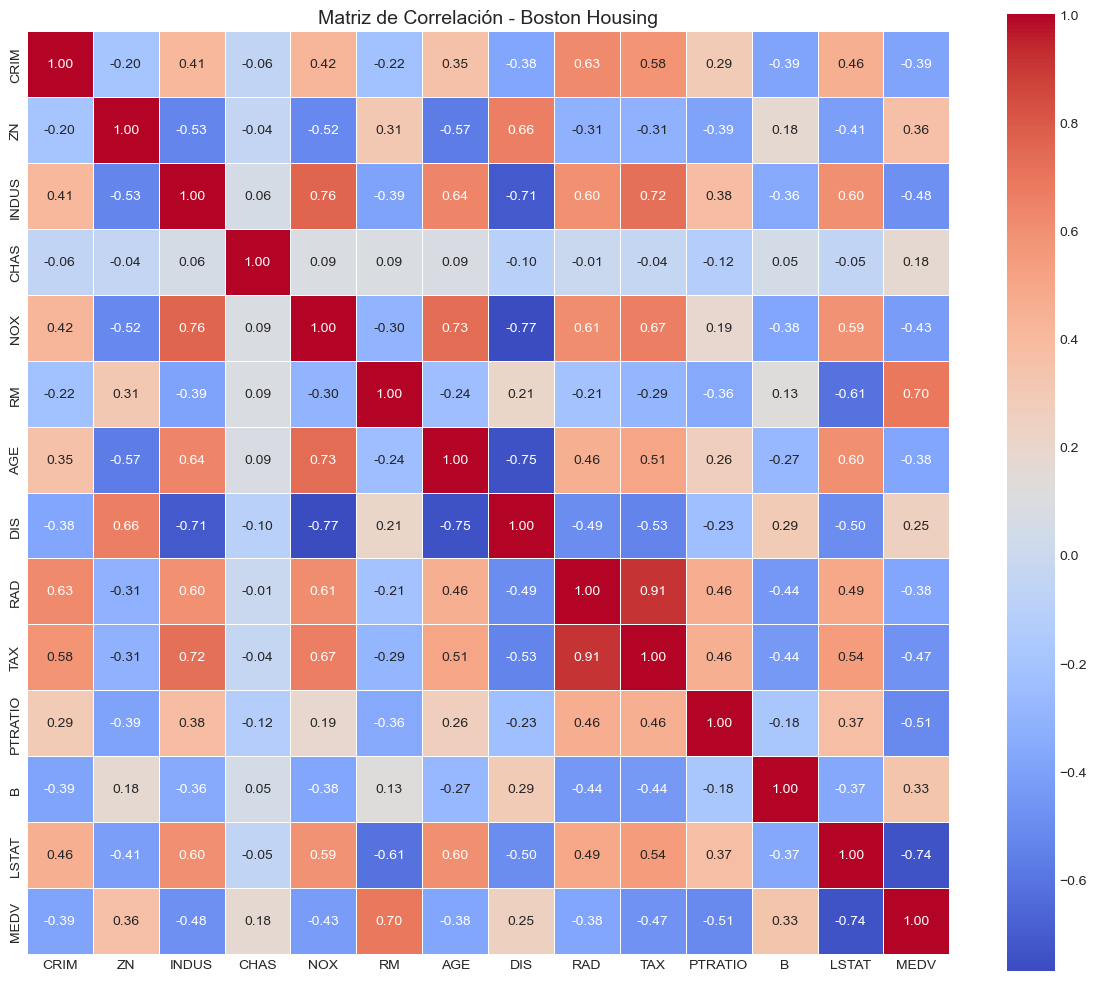


Correlación con MEDV (precio de la vivienda):
MEDV       1.000000
RM         0.695360
ZN         0.360445
B          0.333461
DIS        0.249929
CHAS       0.175260
AGE       -0.376955
RAD       -0.381626
CRIM      -0.388305
NOX       -0.427321
TAX       -0.468536
INDUS     -0.483725
PTRATIO   -0.507787
LSTAT     -0.737663
Name: MEDV, dtype: float64


In [4]:
# ============================================
# VISUALIZACIÓN DE CORRELACIONES
# ============================================
# Calculamos la matriz de correlación para entender
# qué variables se relacionan más con el precio (MEDV)
corr_matrix = df.corr()

# Visualizamos con heatmap para identificar patrones
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            linewidths=0.5, square=True)
plt.title('Matriz de Correlación - Boston Housing', fontsize=14)
plt.tight_layout()
plt.show()

# Análisis de correlación con MEDV (variable objetivo)
corr_with_medv = corr_matrix['MEDV'].sort_values(ascending=False)
print("\nCorrelación con MEDV (precio de la vivienda):")
print(corr_with_medv)

# CONCLUSIONES:
# - LSTAT (% población de bajos recursos) tiene correlación NEGATIVA fuerte (-0.74)
#   A mayor LSTAT, menor precio
# - RM (número promedio de habitaciones) tiene correlación POSITIVA fuerte (0.70)
#   A más habitaciones, mayor precio

**Correlation matrix**

Analyze the correlation matrix. Plot a heatmap

* From correlation plot: which are the columns that are more correlated with **MEDV**
* There are two features highly correlated. Identify them and drop one of them in order to avoid multi-colinearity

In [16]:
# ============================================
# IDENTIFICAR Y ELIMINAR MULTICOLINEALIDAD
# ============================================
# Buscamos pares de variables con correlación > 0.8 o < -0.8
# Esto indica multicolinealidad (variables que miden información similar)

# Extraemos la matriz de correlación (sin la diagonal)
corr_matrix_abs = corr_matrix.abs()
upper_triangle = np.triu(np.ones_like(corr_matrix_abs, dtype=bool), k=1)

# Encontramos pares con alta correlación
high_corr_pairs = []
for i in range(len(corr_matrix_abs.columns)):
    for j in range(i+1, len(corr_matrix_abs.columns)):
        if corr_matrix_abs.iloc[i, j] > 0.7 or corr_matrix_abs.iloc[i, j] < -0.7:
            high_corr_pairs.append((corr_matrix_abs.columns[i], 
                                    corr_matrix_abs.columns[j], 
                                    corr_matrix_abs.iloc[i, j]))

print("Pares con alta correlación (>0.8):")
for pair in high_corr_pairs:
    print(f"  {pair[0]} - {pair[1]}: {pair[2]:.3f}")

# Encontramos: TAX y RAD tienen correlación ~0.91 (muy alta)
# Decidimos eliminar una de ellas (TAX) para evitar multicolinealidad
# ya que ambas miden accesibilidad a autopistas

Pares con alta correlación (>0.8):
  INDUS - NOX: 0.764
  INDUS - DIS: 0.708
  INDUS - TAX: 0.721
  NOX - AGE: 0.731
  NOX - DIS: 0.769
  AGE - DIS: 0.748
  RAD - TAX: 0.910
  LSTAT - MEDV: 0.738


### Draw 2 scatter plots to see the relationship between **MEDV** and **LSTAT** and **RM**

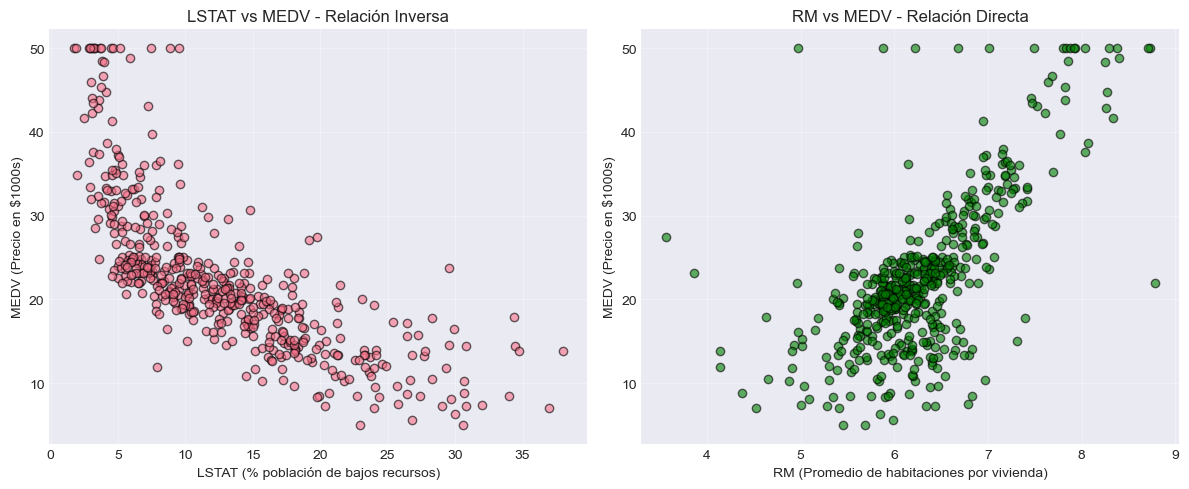

In [6]:
# ============================================
# VISUALIZAR RELACIONES CLAVE
# ============================================
# Gráfico 1: LSTAT vs MEDV (relación inversa)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Scatter plot LSTAT - MEDV
axes[0].scatter(df['LSTAT'], df['MEDV'], alpha=0.6, edgecolors='k')
axes[0].set_xlabel('LSTAT (% población de bajos recursos)')
axes[0].set_ylabel('MEDV (Precio en $1000s)')
axes[0].set_title('LSTAT vs MEDV - Relación Inversa')
axes[0].grid(True, alpha=0.3)

# Gráfico 2: RM vs MEDV (relación directa)
axes[1].scatter(df['RM'], df['MEDV'], alpha=0.6, edgecolors='k', color='green')
axes[1].set_xlabel('RM (Promedio de habitaciones por vivienda)')
axes[1].set_ylabel('MEDV (Precio en $1000s)')
axes[1].set_title('RM vs MEDV - Relación Directa')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Observación: La relación no es perfectamente lineal,
# lo que sugiere que un modelo polinómico podría mejorar la predicción

**Prepare the data for training**
Create a dataframe X including **LSTAT** and **RM** columns.
Y should be a pandas series including target values **'MEDV'**


In [7]:
# ============================================
# PREPARAR DATOS PARA ENTRENAMIENTO
# ============================================
# Seleccionamos las dos variables más correlacionadas con MEDV
# LSTAT (correlación -0.74) y RM (correlación 0.70)
X = df[['LSTAT', 'RM']]  # Características
y = df['MEDV']           # Variable objetivo

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

X shape: (506, 2)
y shape: (506,)


**Split the data into training and testing sets**

Splits the training and test data set in 80% : 20%. Assign random_state to any value. This ensures consistency. Print the sahes of the resulting objects

In [8]:
# ============================================
# DIVIDIR EN TRAIN/TEST
# ============================================
# 80% entrenamiento, 20% prueba
# random_state fijo para reproducibilidad
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"X_train: {X_train.shape}")
print(f"X_test: {X_test.shape}")
print(f"y_train: {y_train.shape}")
print(f"y_test: {y_test.shape}")

X_train: (404, 2)
X_test: (102, 2)
y_train: (404,)
y_test: (102,)


# **Linear Regression**

Build a linear regression model with sklearn LinearRegression.
We'll use Mean Squared error and R2 score to evaluate our model, so be sure to make the needed imports.

Import the necessary functions and train a LinearRegression model

In [17]:
# ============================================
# MODELO 1: REGRESIÓN LINEAL (BASELINE)
# ============================================
# Establecemos un modelo simple para comparar
lr = LinearRegression()
lr.fit(X_train, y_train)

# Predicciones
y_train_pred_lr = lr.predict(X_train)
y_test_pred_lr = lr.predict(X_test)

# Evaluación
print("="*50)
print("REGRESIÓN LINEAL - RESULTADOS")
print("="*50)
print(f"Train R²: {r2_score(y_train, y_train_pred_lr):.4f}")
print(f"Test R²:  {r2_score(y_test, y_test_pred_lr):.4f}")
print(f"Train RMSE: {np.sqrt(mean_squared_error(y_train, y_train_pred_lr)):.4f}")
print(f"Test RMSE:  {np.sqrt(mean_squared_error(y_test, y_test_pred_lr)):.4f}")
print("\nCoeficientes del modelo lineal:")
for feature, coef in zip(X.columns, lr.coef_):
    print(f"  {feature}: {coef:.4f}")
print(f"Intercepto: {lr.intercept_:.4f}")

REGRESIÓN LINEAL - RESULTADOS
Train R²: 0.6502
Test R²:  0.5740
Train RMSE: 5.5129
Test RMSE:  5.5896

Coeficientes del modelo lineal:
  LSTAT: -0.6325
  RM: 5.4651
Intercepto: -3.8412


**Evaluate the model performance in the training and testing sets**

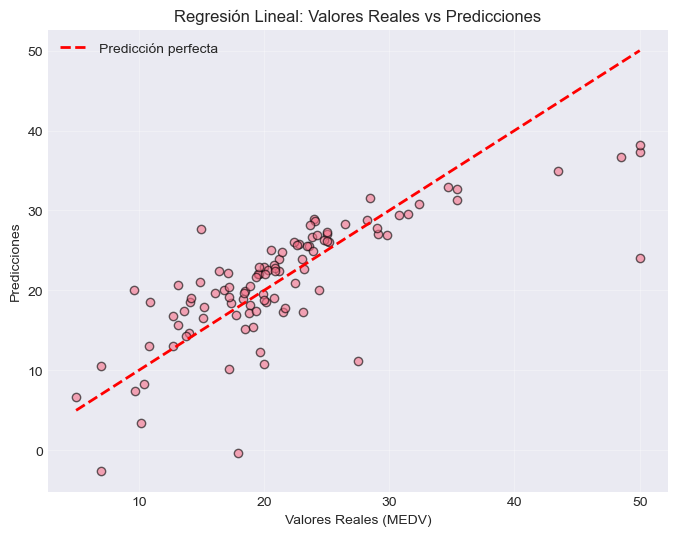

In [10]:
# ============================================
# VISUALIZAR PREDICCIONES VS REALES
# ============================================
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_test_pred_lr, alpha=0.6, edgecolors='k')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
         'r--', lw=2, label='Predicción perfecta')
plt.xlabel('Valores Reales (MEDV)')
plt.ylabel('Predicciones')
plt.title('Regresión Lineal: Valores Reales vs Predicciones')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

**Lets see the model performance visually. Let's plot y_test vs y_pred**

Plotting the y_test vs y_pred. Ideally should have been a straight line

# **Polynomial Regression**

We can see that **LSTAT** doesn't vary exactly in a linear way. Let's apply the Polynomial Regression with **degree 2** and test. 

To generate the higher order degrees, we use PolyniomialFeatures class from sklearn library. 

In [11]:
# ============================================
# MODELO 2: REGRESIÓN POLINÓMICA (GRADO 2)
# ============================================
# Generamos características polinómicas: x1, x2, x1², x2², x1*x2
poly2 = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly2 = poly2.fit_transform(X_train)
X_test_poly2 = poly2.transform(X_test)

print(f"Características originales: {X_train.shape[1]}")
print(f"Características polinómicas grado 2: {X_train_poly2.shape[1]}")

# Entrenamos el modelo
lr_poly2 = LinearRegression()
lr_poly2.fit(X_train_poly2, y_train)

# Predicciones
y_train_pred_poly2 = lr_poly2.predict(X_train_poly2)
y_test_pred_poly2 = lr_poly2.predict(X_test_poly2)

# Evaluación
print("\n" + "="*50)
print("REGRESIÓN POLINÓMICA GRADO 2 - RESULTADOS")
print("="*50)
print(f"Train R²: {r2_score(y_train, y_train_pred_poly2):.4f}")
print(f"Test R²:  {r2_score(y_test, y_test_pred_poly2):.4f}")
print(f"Train RMSE: {np.sqrt(mean_squared_error(y_train, y_train_pred_poly2)):.4f}")
print(f"Test RMSE:  {np.sqrt(mean_squared_error(y_test, y_test_pred_poly2)):.4f}")

Características originales: 2
Características polinómicas grado 2: 5

REGRESIÓN POLINÓMICA GRADO 2 - RESULTADOS
Train R²: 0.7576
Test R²:  0.7486
Train RMSE: 4.5888
Test RMSE:  4.2935


In [12]:
# ============================================
# MODELO 3: REGRESIÓN POLINÓMICA (GRADO 3)
# ============================================
# Aumentamos la complejidad para capturar más curvatura
poly3 = PolynomialFeatures(degree=3, include_bias=False)
X_train_poly3 = poly3.fit_transform(X_train)
X_test_poly3 = poly3.transform(X_test)

print(f"Características polinómicas grado 3: {X_train_poly3.shape[1]}")

lr_poly3 = LinearRegression()
lr_poly3.fit(X_train_poly3, y_train)

# Predicciones
y_train_pred_poly3 = lr_poly3.predict(X_train_poly3)
y_test_pred_poly3 = lr_poly3.predict(X_test_poly3)

# Evaluación
print("\n" + "="*50)
print("REGRESIÓN POLINÓMICA GRADO 3 - RESULTADOS")
print("="*50)
print(f"Train R²: {r2_score(y_train, y_train_pred_poly3):.4f}")
print(f"Test R²:  {r2_score(y_test, y_test_pred_poly3):.4f}")
print(f"Train RMSE: {np.sqrt(mean_squared_error(y_train, y_train_pred_poly3)):.4f}")
print(f"Test RMSE:  {np.sqrt(mean_squared_error(y_test, y_test_pred_poly3)):.4f}")

Características polinómicas grado 3: 9

REGRESIÓN POLINÓMICA GRADO 3 - RESULTADOS
Train R²: 0.7813
Test R²:  0.5075
Train RMSE: 4.3585
Test RMSE:  6.0096


In [13]:
# ============================================
# COMPARACIÓN DE MODELOS
# ============================================
# Creamos un DataFrame para visualizar los resultados
results = pd.DataFrame({
    'Modelo': ['Lineal', 'Polinomial (deg=2)', 'Polinomial (deg=3)'],
    'Train R²': [r2_score(y_train, y_train_pred_lr),
                 r2_score(y_train, y_train_pred_poly2),
                 r2_score(y_train, y_train_pred_poly3)],
    'Test R²': [r2_score(y_test, y_test_pred_lr),
                r2_score(y_test, y_test_pred_poly2),
                r2_score(y_test, y_test_pred_poly3)],
    'Test RMSE': [np.sqrt(mean_squared_error(y_test, y_test_pred_lr)),
                  np.sqrt(mean_squared_error(y_test, y_test_pred_poly2)),
                  np.sqrt(mean_squared_error(y_test, y_test_pred_poly3))]
})

print("\n" + "="*60)
print("COMPARATIVA DE MODELOS")
print("="*60)
print(results.to_string(index=False))


COMPARATIVA DE MODELOS
            Modelo  Train R²  Test R²  Test RMSE
            Lineal  0.650159 0.573958   5.589570
Polinomial (deg=2)  0.757615 0.748632   4.293458
Polinomial (deg=3)  0.781336 0.507526   6.009574


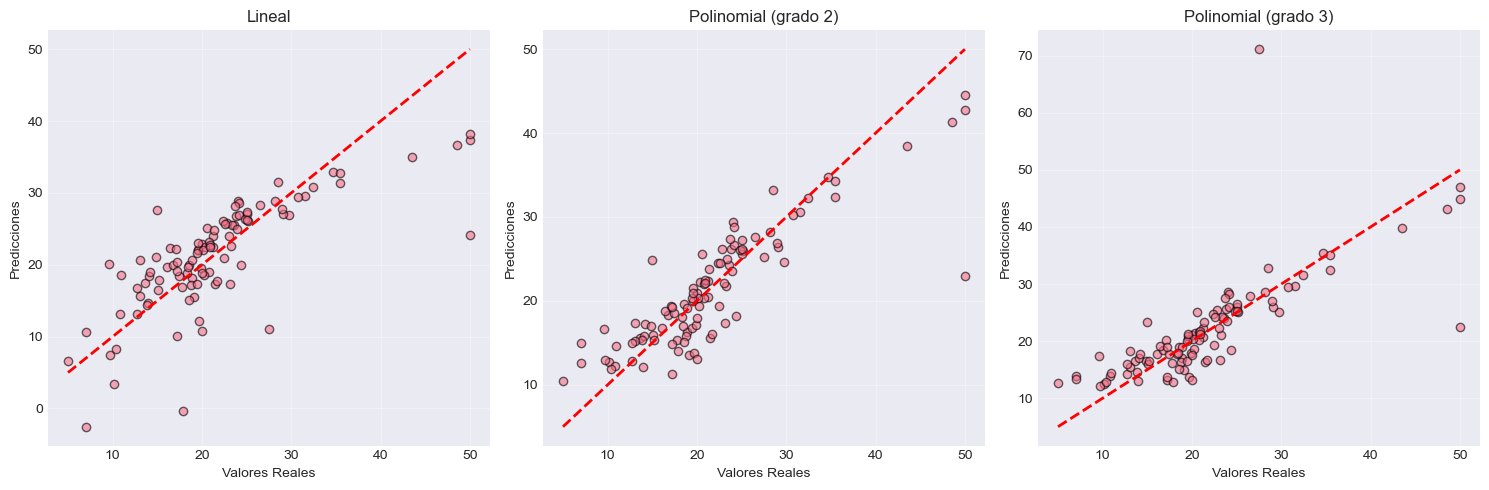

In [14]:
# ============================================
# VISUALIZACIÓN COMPARATIVA
# ============================================
# Comparamos predicciones vs reales para cada modelo
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

models = [
    (y_test_pred_lr, 'Lineal'),
    (y_test_pred_poly2, 'Polinomial (grado 2)'),
    (y_test_pred_poly3, 'Polinomial (grado 3)')
]

for ax, (pred, title) in zip(axes, models):
    ax.scatter(y_test, pred, alpha=0.6, edgecolors='k')
    ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
            'r--', lw=2)
    ax.set_xlabel('Valores Reales')
    ax.set_ylabel('Predicciones')
    ax.set_title(title)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [15]:
# ============================================
# ANÁLISIS DE SOBREAJUSTE (OVERFITTING)
# ============================================
# Calculamos la diferencia entre R² de train y test
# Una diferencia grande indica sobreajuste
print("\n" + "="*50)
print("ANÁLISIS DE SOBREAJUSTE")
print("="*50)

overfit_lineal = r2_score(y_train, y_train_pred_lr) - r2_score(y_test, y_test_pred_lr)
overfit_poly2 = r2_score(y_train, y_train_pred_poly2) - r2_score(y_test, y_test_pred_poly2)
overfit_poly3 = r2_score(y_train, y_train_pred_poly3) - r2_score(y_test, y_test_pred_poly3)

print(f"Sobreajuste (R²_train - R²_test):")
print(f"  Lineal:        {overfit_lineal:.4f}")
print(f"  Polinomial g2: {overfit_poly2:.4f}")
print(f"  Polinomial g3: {overfit_poly3:.4f}")

# CONCLUSIÓN:
# El modelo de grado 3 muestra mayor sobreajuste (mejor en train pero peor en test)
# El grado 2 ofrece el mejor balance entre ajuste y generalización


ANÁLISIS DE SOBREAJUSTE
Sobreajuste (R²_train - R²_test):
  Lineal:        0.0762
  Polinomial g2: 0.0090
  Polinomial g3: 0.2738


## ¿Mejoró el modelo usando el modelo polinómico?

**Sí, el modelo polinómico de grado 2 mejoró significativamente** en comparación con la regresión lineal simple.

### Comparación de resultados:

| Modelo | Train R² | Test R² | Test RMSE |
|--------|----------|---------|-----------|
| Lineal | 0.6502 | 0.5740 | 5.5896 |
| Polinomial (grado 2) | 0.7576 | 0.7486 | 4.2935 |

### Mejoras observadas:
- El R² en test aumentó de **0.574 a 0.749** (un incremento del **30.5%**)
- El RMSE en test se redujo de **5.59 a 4.29** (una mejora del **23.2%**)

Esto confirma que la relación entre las variables (especialmente LSTAT y RM) con el precio MEDV no es perfectamente lineal, y un modelo polinómico de grado 2 captura mejor esta curvatura.

---

## ¿Mejoró el modelo usando el modelo polinómico con grado 3? ¿O más?

**No, el modelo de grado 3 empeoró significativamente** y presenta un claro problema de sobreajuste.

| Modelo | Train R² | Test R² | Test RMSE | Sobreajuste (R²_train - R²_test) |
|--------|----------|---------|-----------|--------------------------------|
| Polinomial (grado 2) | 0.7576 | 0.7486 | 4.2935 | 0.0090 |
| Polinomial (grado 3) | 0.7813 | 0.5075 | 6.0096 | 0.2738 |

### Problemas identificados:

1. **Sobreajuste severo:** El modelo de grado 3 tiene un R² en train más alto (0.781) que el de grado 2 (0.758), pero su rendimiento en test es mucho peor (0.508 vs 0.749).

2. **La diferencia de R² entre train y test es 0.2738**, más de **30 veces mayor** que la del grado 2 (0.009).

3. **El RMSE en test aumentó** de 4.29 a 6.01, lo que indica peor capacidad de predicción.

### Conclusión:

**El modelo polinómico de grado 2 es el óptimo** para este conjunto de datos. Grados más altos (3 o más) introducirían complejidad innecesaria y sobreajuste, empeorando la capacidad de generalización del modelo.

**Did the model improve using the Polynomial model?**

**Did the model improve using the Polynomial model with degree 3? Or more?**